In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen/qwen3-vl-30b-a3b-thinking",
    base_url=os.getenv("OPENAI_URL"),
    temperature=0.7,
    max_tokens=150,
    api_key=os.getenv("OPENAI_API"),
)



In [3]:
llm.invoke("hello")

AIMessage(content='Hello! 😊 How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 324, 'prompt_tokens': 11, 'total_tokens': 335, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 310, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': None, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-vl-30b-a3b-thinking', 'system_fingerprint': None, 'id': 'gen-1772185590-m3qgcgymSvMa0dtodF0K', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c9e7e-0415-7122-842f-1bf36b710859-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 324, 'total_tokens': 335, 'input_token_details': {'

In [ ]:
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}  # must be a list

In [ ]:
graphbuilder=StateGraph(State)
graphbuilder

In [ ]:


graphbuilder.add_node("llmchatbot",chatbot)

graphbuilder.add_edge(START,"llmchatbot")
graphbuilder.add_edge("llmchatbot",END)


graph=graphbuilder.compile()

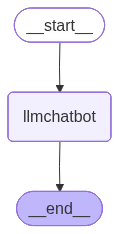

In [ ]:
graph

In [ ]:
# def rag(data):
#     print("RAG called with data:", data)
#     return True

In [ ]:
# graphbuilder.add_node("RAG",rag)
# graphbuilder.add_edge("llmchatbot","RAG")
# graphbuilder.add_edge("RAG","llmchatbot")

In [ ]:
# graph=graphbuilder.compile()

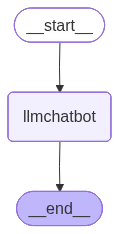

In [ ]:
graph

In [ ]:
graph.invoke({"messages":"hi i am kunal"})

{'messages': [HumanMessage(content='hi i am kunal', additional_kwargs={}, response_metadata={}, id='62b4f4a0-d474-4a01-8c42-1782bd6f200b'),
  AIMessage(content='Hi Kunal! Nice to meet you. How can I assist you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 287, 'prompt_tokens': 15, 'total_tokens': 302, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 266, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': None, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-vl-30b-a3b-thinking', 'system_fingerprint': None, 'id': 'gen-1772084457-OwdNkKpeid9UccgI0XnB', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c9876-ee9b-79f2-a

In [ ]:
graph.invoke({"messages":"what is my name"})

{'messages': [HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='39563e88-d47b-4326-ab70-30f0becb4665'),
  AIMessage(content='I don\'t have access to your personal information or any memory of past conversations unless you share it with me directly in the current chat. **I don\'t know your name** because I don\'t store personal data between sessions, and I can\'t see or recall details about you unless you tell me.  \n\nIf you\'d like to share your name (or a nickname you prefer), I’d be happy to use it going forward! Just say something like:  \n> *"My name is [Your Name]."*  \n\nOtherwise, I\'ll keep things simple and friendly—no pressure. 😊 Let me know how you\'d like to proceed!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 397, 'prompt_tokens': 14, 'total_tokens': 411, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 266, 'rejected_predicti

In [4]:
from langchain_tavily import TavilySearch
from openai import api_key

tool=TavilySearch(max_results=3)
tool.invoke("What is the claude skills")

{'query': 'What is the claude skills',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://simonwillison.net/2025/Oct/16/claude-skills/',
   'title': 'Claude Skills are awesome, maybe a bigger deal than MCP',
   'content': 'Anthropic this morning introduced Claude Skills, a new pattern for making new abilities available to their models:. Skills are folders that include instructions, scripts, and resources that Claude can load when needed. Claude’s new document creation abilities, which accompanied their new code interpreter feature in September, turned out to be entirely implemented using skills. Slack GIFs need to be a maximum of 2MB, so the skill includes a validation function which the model can use to check the file size. The fact that skills are so powerful and simple to create is yet another argument in favor of making safe coding environments available to LLMs. The word **safe** there is doing a *lot* of work though! This is **Claude Skill

In [5]:
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
    a (int): first number
    b (int): second number
    
    Returns:
    int: the product of a and b
    """
    return a*b

In [6]:
tools=[tool,multiply]

In [7]:
llm_with_tools=llm.bind_tools(tools)

In [8]:
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001A62AF0BA10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001A62B704590>, root_client=<openai.OpenAI object at 0x000001A62AF08EC0>, root_async_client=<openai.AsyncOpenAI object at 0x000001A62B7042F0>, model_name='qwen/qwen3-vl-30b-a3b-thinking', temperature=0.7, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', max_tokens=150), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.In

In [35]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


In [17]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [18]:
def tool_calling_llm(state:State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}  # must be a list

In [37]:
builder= StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))



builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition

)

builder.add_edge("tools","tool_calling_llm")
graph=builder.compile(checkpointer=memory)


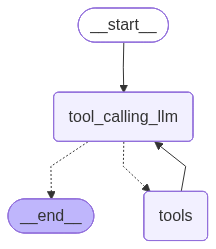

In [38]:
graph

In [39]:
config={"configurable":{"thread_id":"1"}}

In [43]:
response=graph.invoke({"messages":"hi what is my name"},config=config)

In [44]:
response["messages"][-1].content

'Your name is Kunal! 😊 I remember you mentioned it earlier. How can I help you today?'

In [45]:
print(response["messages"][-1].content)

Your name is Kunal! 😊 I remember you mentioned it earlier. How can I help you today?


In [47]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

hi my name is kunal
================================== Ai Message ==================================

Hello Kunal! How can I assist you today? 😊
================================ Human Message =================================

hi what is my name
================================== Ai Message ==================================

Your name is Kunal! 😊 I remember you mentioned it earlier. How can I help you today?
